In [1]:
# ---- Reproducibility
import random
import torch

#seed = 1234
#random.seed(seed)
#torch.manual_seed(seed)
#if torch.cuda.is_available():
#    torch.cuda.manual_seed_all(seed)


In [2]:


# ---- Parameters
n, p = 50, 40
noise_std = 0.1

# (Optional) choose device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---- Data generation (PyTorch)
# Use float64 to mirror NumPy defaults
u = torch.rand(n, dtype=torch.float64, device=device)          # length n
v = torch.rand(p, dtype=torch.float64, device=device)          # length p

# Rank-1 matrix via outer product
rank_1_matrix = torch.outer(u, v)                              # (n, p)

# Homoscedastic Gaussian noise
noise = noise_std * torch.randn(n, p, dtype=torch.float64, device=device)

noisy_matrix = rank_1_matrix + noise

# ---- Print (move to CPU for readability if needed)
print("Rank-1 Matrix (Outer Product):")
print(rank_1_matrix.cpu().numpy())

print("\nNoisy Matrix (with Homoscedastic Noise):")
print(noisy_matrix.cpu().numpy())


Rank-1 Matrix (Outer Product):
[[0.02705051 0.01501745 0.00367856 ... 0.00731665 0.01438062 0.02390084]
 [0.41818454 0.23216068 0.05686837 ... 0.113111   0.2223158  0.36949266]
 [0.60707884 0.33702785 0.08255586 ... 0.16420333 0.32273603 0.5363928 ]
 ...
 [0.13339571 0.07405639 0.01814031 ... 0.03608101 0.070916   0.1178636 ]
 [0.25230157 0.14006856 0.03431016 ... 0.0682428  0.13412889 0.2229245 ]
 [0.25843526 0.14347376 0.03514427 ... 0.06990185 0.13738969 0.22834401]]

Noisy Matrix (with Homoscedastic Noise):
[[ 0.07232318  0.09254358 -0.11157312 ...  0.13856899  0.16600359
   0.00613019]
 [ 0.42679179  0.14771541  0.12789895 ...  0.15530171  0.05628819
   0.31318028]
 [ 0.57861736  0.32620216  0.17341712 ...  0.34154243  0.25743289
   0.47616518]
 ...
 [ 0.19817082  0.14452402  0.10083724 ...  0.03985627 -0.00773837
   0.34044178]
 [ 0.31277752  0.19765326  0.12263628 ...  0.18441271  0.24839108
   0.371484  ]
 [ 0.2984998   0.04826305 -0.25337619 ... -0.17093437  0.29704912
   0.20

In [3]:
import sys
import os
import matplotlib.pyplot as plt
from cebmf_torch import cEBMF

In [4]:
mycebmf=  cEBMF(data= noisy_matrix, prior_F="exp",
                prior_L="exp") 

 

In [5]:
mycebmf.initialise_factors()
print(mycebmf.L[:,1])
print(mycebmf.F[:,1])

tensor([-0.0041,  0.0597, -0.1005,  0.2152, -0.2679,  0.0081,  0.1858,  0.2304,
         0.0688, -0.2223,  0.1312,  0.0590, -0.3226,  0.1955, -0.0694,  0.1112,
        -0.3062,  0.1123, -0.0804,  0.3498, -0.1729, -0.2230, -0.1037,  0.0556,
         0.1344,  0.1580, -0.1208, -0.2394, -0.1222,  0.1327, -0.1550,  0.0291,
         0.2800, -0.3392,  0.0125, -0.0814,  0.0485,  0.3717,  0.0085, -0.2446,
         0.1171, -0.2961, -0.0504, -0.2155,  0.1831,  0.0151,  0.0551, -0.5096,
        -0.0614,  0.1306])
tensor([ 0.0142,  0.0225, -0.1938,  0.1463, -0.1004,  0.0279, -0.0409, -0.0502,
         0.1048, -0.1665,  0.0720,  0.3734,  0.2607,  0.0236,  0.0225, -0.0380,
        -0.1695,  0.0345, -0.0075, -0.0342,  0.1616,  0.2451, -0.0318, -0.1685,
        -0.1295, -0.1350,  0.2021, -0.1296,  0.1990, -0.1551,  0.2103,  0.3227,
        -0.2622,  0.0455, -0.1614,  0.2011, -0.2663,  0.0344, -0.0590, -0.0848])


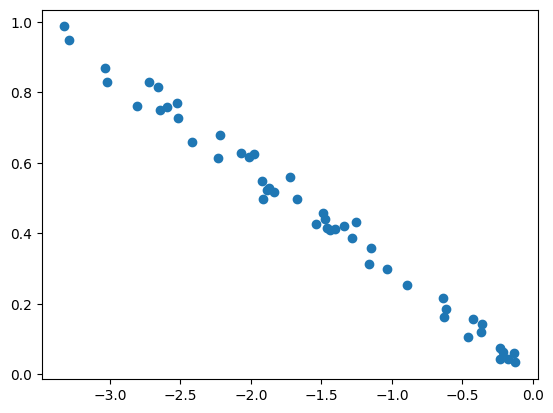

In [6]:
plt.scatter( mycebmf.L[:,0],u)

In [7]:
mycebmf.iter_once()
mycebmf._update_fitted_value()
import numpy as np
K=0
mycebmf.Y_fit 

tensor([[0.0790, 0.0820, 0.0055,  ..., 0.0068, 0.0866, 0.0984],
        [0.0553, 0.0256, 0.0070,  ..., 0.0109, 0.0258, 0.0469],
        [0.0095, 0.0048, 0.0011,  ..., 0.0020, 0.0053, 0.0086],
        ...,
        [0.0680, 0.0657, 0.0057,  ..., 0.0045, 0.0673, 0.0808],
        [0.0314, 0.0142, 0.0027,  ..., 0.0053, 0.0241, 0.0323],
        [0.3077, 0.1762, 0.0256,  ..., 0.0472, 0.2546, 0.3289]])

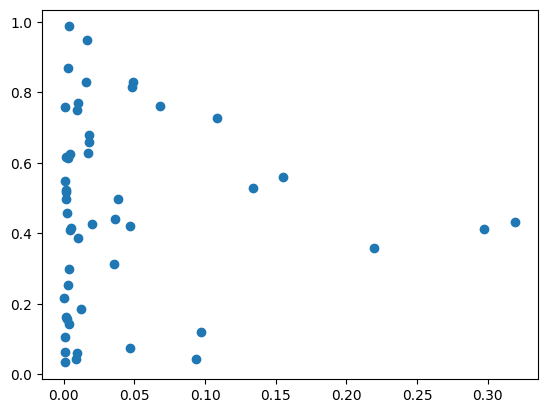

In [8]:
plt.scatter( mycebmf.L[:,0],u)

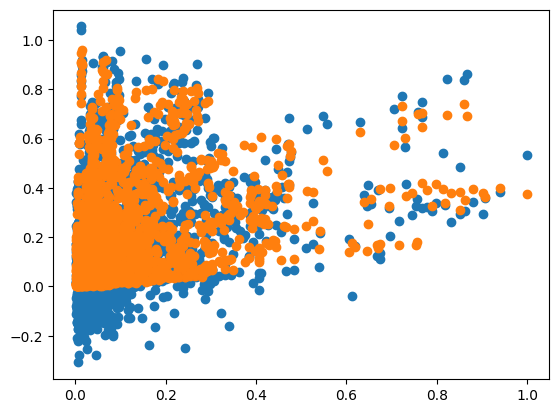

In [9]:
mycebmf.iter_once()  
plt.scatter(mycebmf.Y_fit, noisy_matrix)
 
plt.scatter(mycebmf.Y_fit, rank_1_matrix)

In [10]:
mycebmf.fit()

CEBMFResult(L=tensor([[0.0335, 0.0100, 0.0100],
        [0.3224, 0.0100, 0.0100],
        [0.4834, 0.0100, 0.0100],
        [0.2718, 0.0101, 0.0100],
        [0.2793, 0.0100, 0.0100],
        [0.3847, 0.0100, 0.0100],
        [0.0529, 0.0100, 0.0100],
        [0.2500, 0.0100, 0.0099],
        [0.2235, 0.0099, 0.0099],
        [0.2430, 0.0100, 0.0100],
        [0.0334, 0.0099, 0.0099],
        [0.3517, 0.0100, 0.0100],
        [0.0209, 0.0100, 0.0100],
        [0.3663, 0.0100, 0.0100],
        [0.2874, 0.0100, 0.0100],
        [0.1686, 0.0100, 0.0100],
        [0.3769, 0.0100, 0.0099],
        [0.2141, 0.0100, 0.0100],
        [0.0511, 0.0100, 0.0099],
        [0.2038, 0.0100, 0.0100],
        [0.0607, 0.0100, 0.0100],
        [0.2670, 0.0100, 0.0099],
        [0.3248, 0.0100, 0.0100],
        [0.3012, 0.0100, 0.0100],
        [0.3963, 0.0100, 0.0099],
        [0.4084, 0.0099, 0.0099],
        [0.1295, 0.0100, 0.0099],
        [0.0908, 0.0100, 0.0100],
        [0.4416, 0.0100, 0.0100],


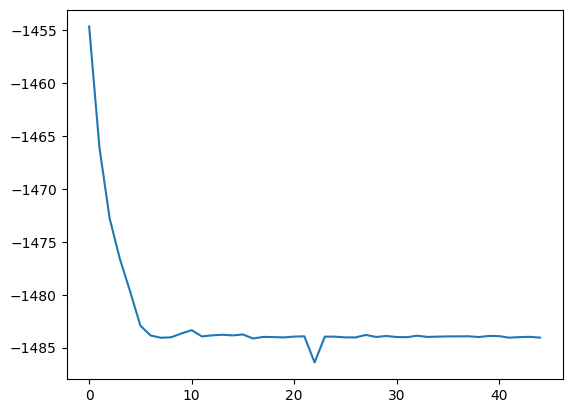

In [11]:
plt.plot(mycebmf.obj)

tensor(0.1000, dtype=torch.float64)

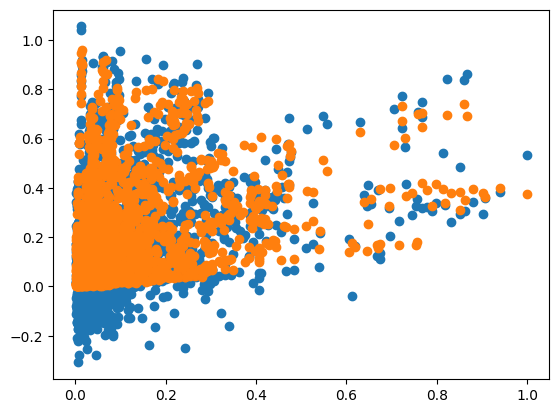

In [12]:
plt.scatter(mycebmf.Y_fit, noisy_matrix)
 
plt.scatter(mycebmf.Y_fit, rank_1_matrix)
torch.sqrt(torch.mean(mycebmf.Y_fit- rank_1_matrix)**2)

In [13]:
results =[]
for i in range(50):
    # Parameters
    n, p = 50, 40
    noise_std = 0.1

# (Optional) choose device
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---- Data generation (PyTorch)
# Use float64 to mirror NumPy defaults
    u = torch.rand(n, dtype=torch.float64, device=device)          # length n
    v = torch.rand(p, dtype=torch.float64, device=device)          # length p

# Rank-1 matrix via outer product
    rank_1_matrix = torch.outer(u, v)                              # (n, p)

# Homoscedastic Gaussian noise
    noise = noise_std * torch.randn(n, p, dtype=torch.float64, device=device)

    noisy_matrix = rank_1_matrix + noise

 
# Add homoscedastic Gaussian noise (constant variance across the matrix)
    mycebmf=  cEBMF(data= noisy_matrix,prior_L="exp",
                    prior_F="exp") 
    mycebmf.initialise_factors()
    mycebmf.fit()
    
    mycebmf._update_fitted_value()
    
    rr = torch.sqrt(torch.mean((mycebmf.Y_fit- rank_1_matrix)**2))
    results.append( rr)
    res= np.asarray(results)
    print(np.mean(res ))
 

0.020372089473547492
0.021149724982188717
0.021810133598769776
0.02155195297213292
0.021458315938085868
0.02167633979632252
0.021248404684851056
0.02167313163590446
0.021786175671320913
0.021543393033037136
0.021568924894668065
0.021694922374881066
0.021629072223377194
0.021749692870352257
0.02166655646195649
0.02172361903758066
0.021767659846228114
0.02184192788340826
0.02179356741838781
0.021743777949490797
0.02177352738656798
0.021688259466027527
0.02175818245722943
0.02178658027884894
0.021691600799207723
0.02170061261120985
0.021693988189312452
0.02153217099119954
0.021478652453407694
0.021521920130338577
0.021554601446127246
0.021625997541181732
0.02154924257658383
0.02153728056732325
0.021541677897655553
0.02154235933825676
0.02150803142678445
0.02151400780500038
0.021495606707495698
0.02142677010726126
0.02137094721584827
0.021357501446759058
0.021318916426623626
0.02134570809825133
0.02145428353482545
0.02142389164216229
0.0214122593670368
0.02140246783751192
0.021399602269645

In [14]:
i


49

In [15]:
results

[tensor(0.0204, dtype=torch.float64),
 tensor(0.0219, dtype=torch.float64),
 tensor(0.0231, dtype=torch.float64),
 tensor(0.0208, dtype=torch.float64),
 tensor(0.0211, dtype=torch.float64),
 tensor(0.0228, dtype=torch.float64),
 tensor(0.0187, dtype=torch.float64),
 tensor(0.0246, dtype=torch.float64),
 tensor(0.0227, dtype=torch.float64),
 tensor(0.0194, dtype=torch.float64),
 tensor(0.0218, dtype=torch.float64),
 tensor(0.0231, dtype=torch.float64),
 tensor(0.0208, dtype=torch.float64),
 tensor(0.0233, dtype=torch.float64),
 tensor(0.0205, dtype=torch.float64),
 tensor(0.0226, dtype=torch.float64),
 tensor(0.0225, dtype=torch.float64),
 tensor(0.0231, dtype=torch.float64),
 tensor(0.0209, dtype=torch.float64),
 tensor(0.0208, dtype=torch.float64),
 tensor(0.0224, dtype=torch.float64),
 tensor(0.0199, dtype=torch.float64),
 tensor(0.0233, dtype=torch.float64),
 tensor(0.0224, dtype=torch.float64),
 tensor(0.0194, dtype=torch.float64),
 tensor(0.0219, dtype=torch.float64),
 tensor(0.02

In [23]:
res= np.asarray(results)
np.mean(res )

np.float64(0.021403045026032633)

In [24]:
np.sqrt(np.var(res ))

np.float64(0.0016436085675766501)

In [25]:
import numpy as np
import matplotlib.pyplot as plt

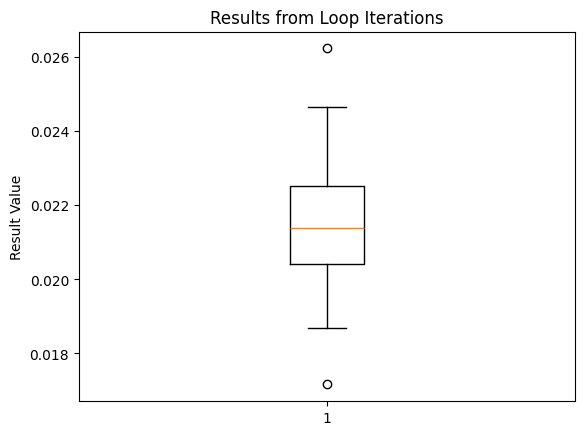

In [26]:
plt.boxplot(results)
plt.title("Results from Loop Iterations")
plt.ylabel("Result Value")
plt.show()

In [27]:
res= np.asarray(results)
np.mean(res )

np.float64(0.021403045026032633)

In [21]:
np.sqrt(np.var(res ))

np.float64(0.0016436085675766501)

tensor(0.0022, dtype=torch.float64)

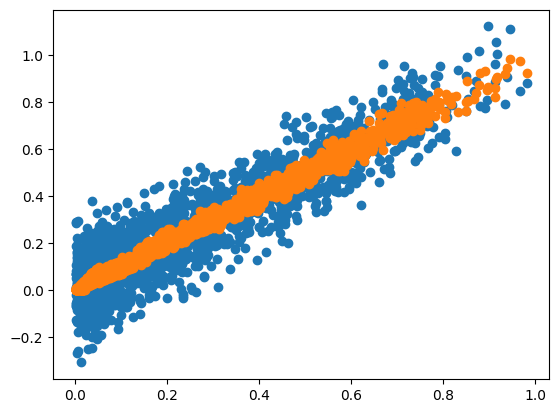

In [22]:
mycebmf._update_fitted_value()
plt.scatter(mycebmf.Y_fit, noisy_matrix)
 
plt.scatter(mycebmf.Y_fit, rank_1_matrix)
torch.sqrt(torch.mean(mycebmf.Y_fit- rank_1_matrix)**2)